# Step 1: Load Dataset and Initial Understanding

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("sales_data_with_discounts.csv")

In [7]:
# Display first 5 rows
print("First 5 Rows of Dataset:\n")
print(df.head())

First 5 Rows of Dataset:

         Date       Day  SKU City  Volume       BU  Brand       Model  \
0  01-04-2021  Thursday  M01    C      15  Mobiles  RealU       RU-10   
1  01-04-2021  Thursday  M02    C      10  Mobiles  RealU   RU-9 Plus   
2  01-04-2021  Thursday  M03    C       7  Mobiles   YouM       YM-99   
3  01-04-2021  Thursday  M04    C       6  Mobiles   YouM  YM-99 Plus   
4  01-04-2021  Thursday  M05    C       3  Mobiles   YouM      YM-98    

   Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0      12100             181500          11.654820     21153.498820   
1      10100             101000          11.560498     11676.102961   
2      16100             112700           9.456886     10657.910157   
3      20100             120600           6.935385      8364.074702   
4       8100              24300          17.995663      4372.946230   

   Net Sales Value  
0    160346.501180  
1     89323.897039  
2    102042.089843  
3    112235.925298  
4  

In [3]:
# Shape of dataset
print("\nShape of Dataset:")
print(df.shape)


Shape of Dataset:
(450, 13)


In [4]:
# Column names
print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['Date', 'Day', 'SKU', 'City', 'Volume', 'BU', 'Brand', 'Model',
       'Avg Price', 'Total Sales Value', 'Discount Rate (%)',
       'Discount Amount', 'Net Sales Value'],
      dtype='object')


In [5]:
# Data types and null values
print("\nDataset Info:\n")
print(df.info())


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    object 
 1   Day                450 non-null    object 
 2   SKU                450 non-null    object 
 3   City               450 non-null    object 
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    object 
 6   Brand              450 non-null    object 
 7   Model              450 non-null    object 
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 45.8+ KB
None


# Step 2 — Identify Numerical Columns + Start Descriptive Statistics

In [8]:
# Select only numerical columns
numerical_columns = df.select_dtypes(include=[np.number])

In [9]:
print("Numerical Columns in Dataset:\n")
print(numerical_columns.columns)

Numerical Columns in Dataset:

Index(['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)',
       'Discount Amount', 'Net Sales Value'],
      dtype='object')


In [10]:
print("\nBasic Statistical Summary:\n")
print(numerical_columns.describe())


Basic Statistical Summary:

           Volume     Avg Price  Total Sales Value  Discount Rate (%)  \
count  450.000000    450.000000         450.000000         450.000000   
mean     5.066667  10453.433333       33812.835556          15.155242   
std      4.231602  18079.904840       50535.074173           4.220602   
min      1.000000    290.000000         400.000000           5.007822   
25%      3.000000    465.000000        2700.000000          13.965063   
50%      4.000000   1450.000000        5700.000000          16.577766   
75%      6.000000  10100.000000       53200.000000          18.114718   
max     31.000000  60100.000000      196400.000000          19.992407   

       Discount Amount  Net Sales Value  
count       450.000000       450.000000  
mean       3346.499424     30466.336131  
std        4509.902963     46358.656624  
min          69.177942       326.974801  
25%         460.459304      2202.208645  
50%         988.933733      4677.788059  
75%        5316.495

# Step 3 — Mean, Median, Mode, Standard Deviation for All Numerical Columns

In [11]:
stats_summary = pd.DataFrame({
    "Mean": numerical_columns.mean(),
    "Median": numerical_columns.median(),
    "Mode": numerical_columns.mode().iloc[0],
    "Standard Deviation": numerical_columns.std()
})

print(stats_summary)

                           Mean       Median          Mode  Standard Deviation
Volume                 5.066667     4.000000      3.000000            4.231602
Avg Price          10453.433333  1450.000000    400.000000        18079.904840
Total Sales Value  33812.835556  5700.000000  24300.000000        50535.074173
Discount Rate (%)     15.155242    16.577766      5.007822            4.220602
Discount Amount     3346.499424   988.933733     69.177942         4509.902963
Net Sales Value    30466.336131  4677.788059    326.974801        46358.656624


# Step 4 — Brief Interpretation of Mean, Median, Mode, and Standard Deviation

**1. Volume**

**Observation**

Mean = 5.07

Median = 4

Mode = 3

Std = 4.23

**Interpretation**

Since the mean is greater than the median, the Volume column is slightly positively skewed (right-skewed), which means some transactions have higher quantities purchased that increase the average.

The mode being 3 shows that most commonly customers purchase around 3 units.

The standard deviation is moderate, which indicates purchase quantity varies across customers but not extremely.

This suggests normal customer buying behavior with some bulk purchases.

**2. Avg Price**

***Observation***

Mean = 10453.43

Median = 1450

Mode = 400

Std = 18079.90

***Interpretation***

There is a huge difference between mean and median, which strongly indicates a highly right-skewed distribution.

A few very expensive products are pulling the average price upward significantly.

The mode being 400 shows that most products are low-priced, but some premium products create a very high average.

The very high standard deviation confirms extreme variation and likely presence of outliers.

This suggests the business sells both low-cost regular products and high-value premium products.

**3. Total Sales Value**

***Observation***

Mean = 33812.84

Median = 5700

Mode = 24300

Std = 50535.07

***Interpretation***

Again, mean is much higher than median, showing strong positive skewness.

A few very large sales transactions are increasing the average sales value.

The extremely high standard deviation shows major variation in transaction values and strong presence of outliers.

This indicates the business handles both small routine transactions and some very large high-value sales.

This is common in retail and wholesale businesses.

**4. Discount Rate (%)**

***Observation***

Mean = 15.16

Median = 16.58

Mode = 5.01

Std = 4.22

***Interpretation***

Here, mean is slightly lower than median, suggesting a slight left-skew or relatively balanced discount distribution.

The mode being around 5% shows that smaller discounts are most commonly offered.

The standard deviation is low compared to other columns, meaning discount percentages are relatively consistent.

This indicates discount policies are mostly standardized and controlled.

This is a positive business sign.

**5. Discount Amount**

***Observation***

Mean = 3346.50

Median = 988.93

Mode = 69.18

Std = 4509.90

***Interpretation***

The large gap between mean and median shows strong right skewness.

A few transactions receive very large discounts, increasing the average significantly.

The mode being very low indicates that most transactions receive small discounts.

The high standard deviation suggests inconsistent discount amounts and possible extreme discount cases.

This may require management review to ensure discount strategies remain profitable.

**6. Net Sales Value**

***Observation***

Mean = 30466.34

Median = 4677.79

Mode = 326.97

Std = 46358.66

***Interpretation***

This column also shows strong positive skewness because mean is far greater than median.

Most transactions are smaller, but a few very large net sales significantly increase the average.

The very high standard deviation indicates large variability and strong outliers.

This suggests revenue concentration may depend heavily on a small number of high-value transactions.

This is a major strategic business insight.

***Overall Business Insight***

**Most financial columns such as:**

Avg Price

Total Sales Value

Discount Amount

Net Sales Value

show strong right-skewness and high standard deviation.


**This indicates:**

presence of outliers

premium product transactions

inconsistent transaction sizes

revenue concentration in fewer high-value sales

While:

**Discount Rate (%)**

shows more consistency, suggesting discount policy is controlled.

# Step 5 — Histograms for Numerical Columns + Distribution Analysis

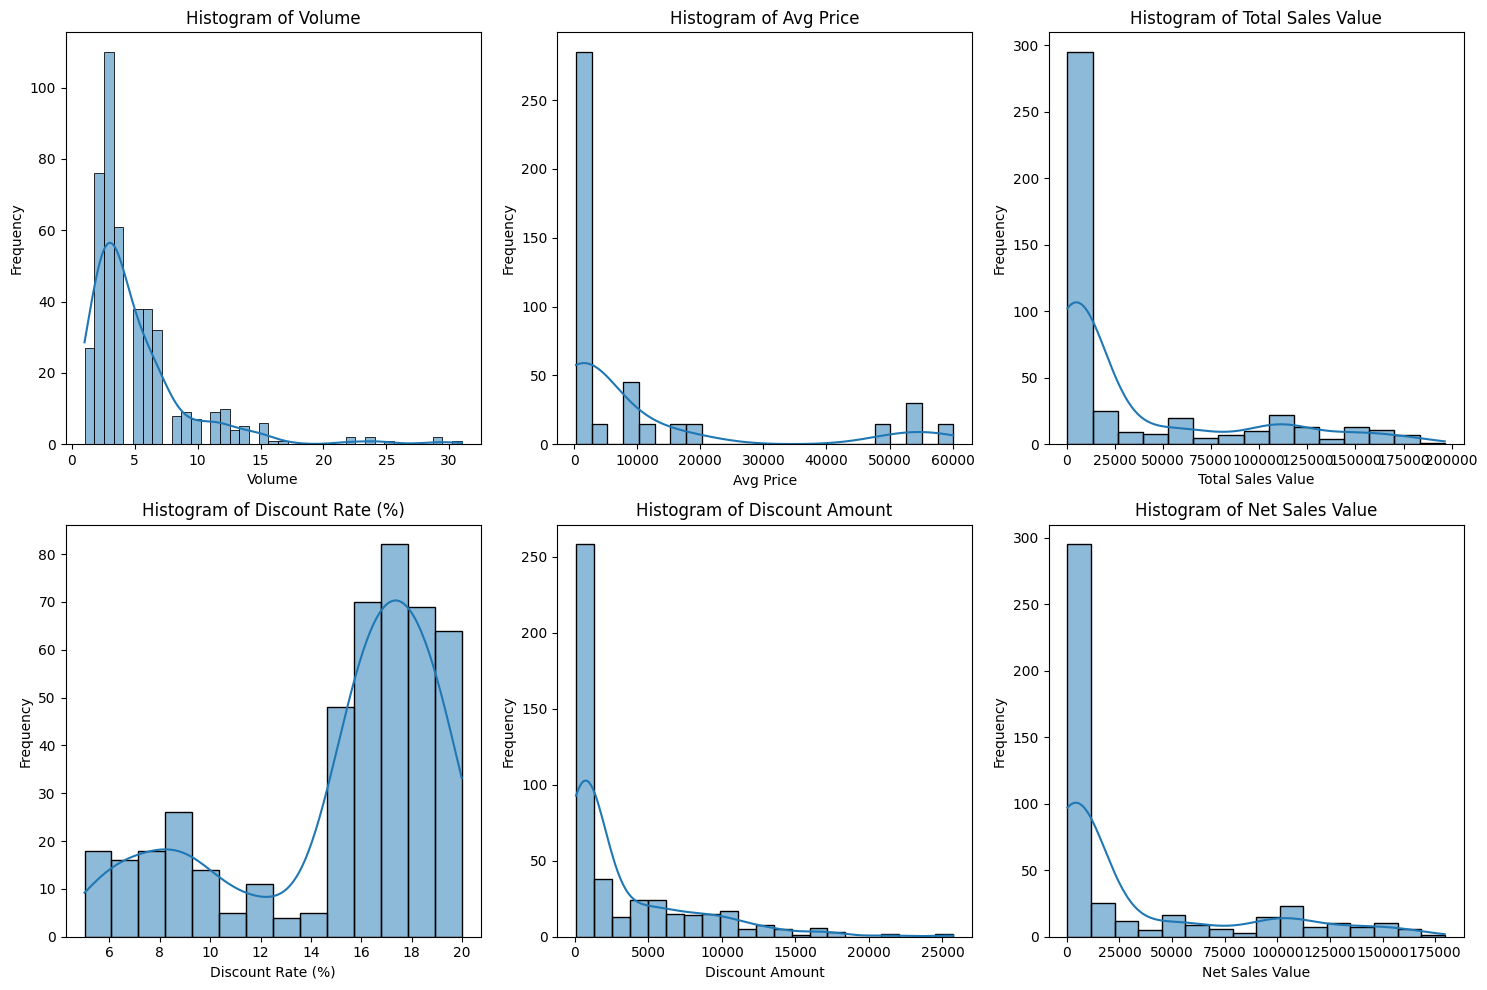

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size for better readability
plt.figure(figsize=(15, 10))

# Plot histogram for each numerical column
for i, column in enumerate(numerical_columns.columns, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[column], kde=True)
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Histogram Interpretation

**Avg Price**

The histogram is highly right-skewed, showing that most products are low-priced while a few premium products have very high prices.

This creates a long right tail and confirms the large difference between mean and median.


**Total Sales Value**

The histogram shows strong positive skewness, indicating most transactions are smaller while a few transactions have very high sales values.

This suggests revenue concentration in fewer large transactions.


**Discount Rate (%)**

The histogram is more balanced and less skewed compared to other columns, indicating discount percentages are relatively controlled and consistent.

This supports the lower standard deviation observed earlier.


**Discount Amount**

The histogram shows right skewness with a few large discount values.

Most discounts are small, but some high-discount transactions create outliers.

This may require profitability review.


**Net Sales Value**

The histogram is highly right-skewed, showing most transactions are smaller while some high-value sales dominate total revenue.

This indicates dependence on fewer high-value customers or orders.

# Step 6 — Boxplots for Outlier Detection + IQR Analysis

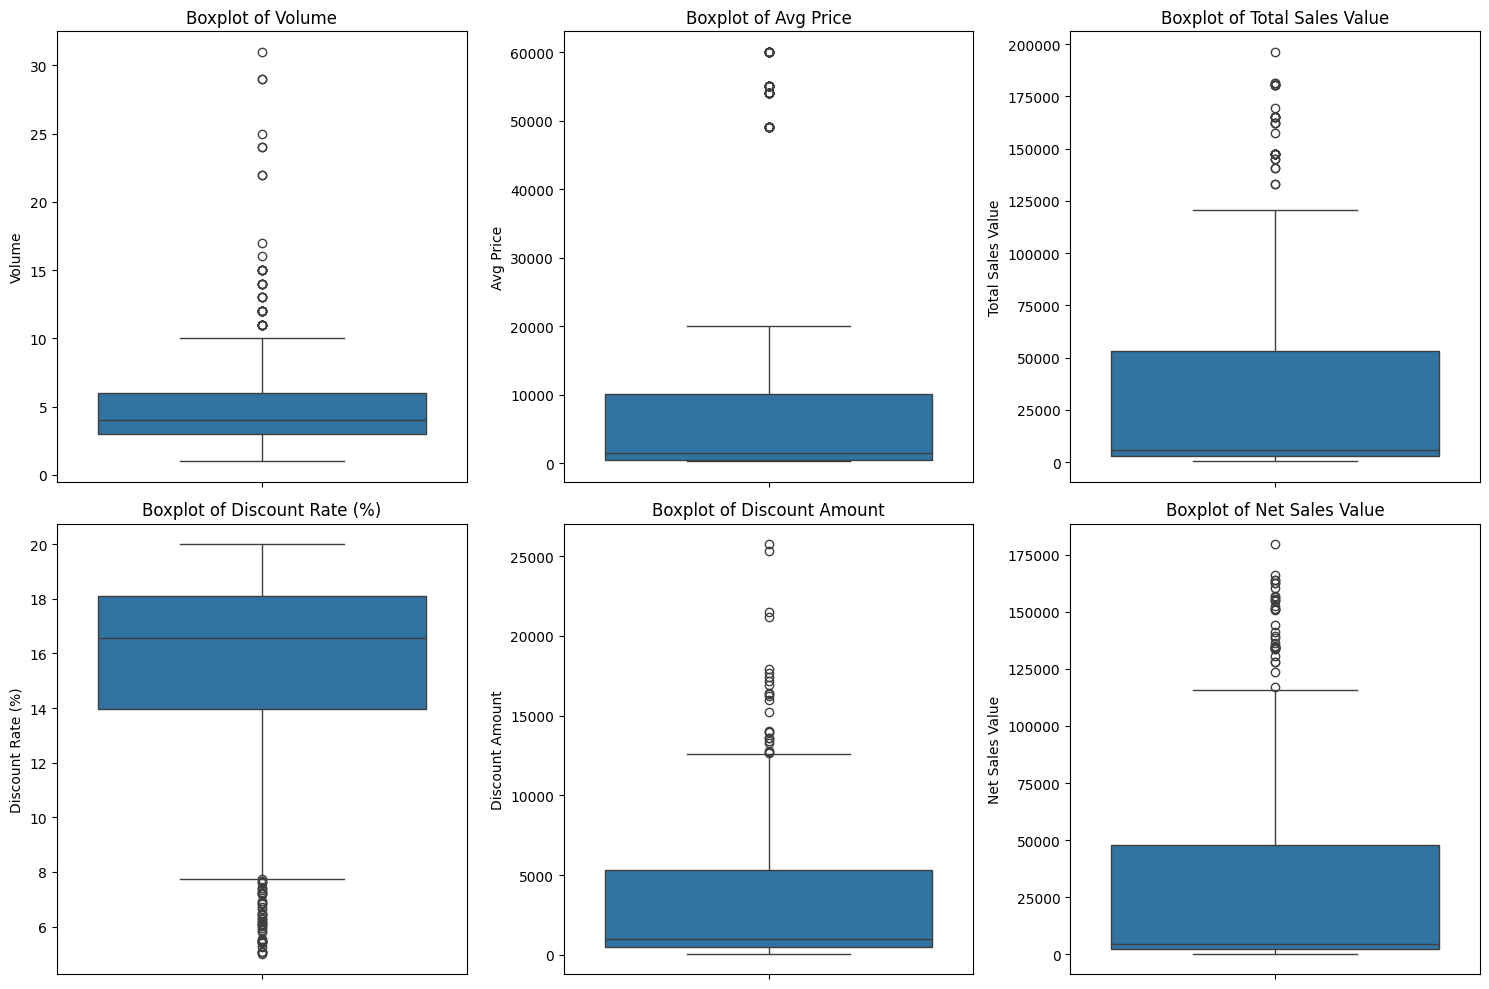

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(15, 10))

# Plot boxplot for each numerical column
for i, column in enumerate(numerical_columns.columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[column])
    plt.title(f"Boxplot of {column}")
    plt.ylabel(column)

plt.tight_layout()
plt.show()

# Boxplot Interpretation

***Avg Price***

The boxplot shows several upper-side outliers, indicating a few very expensive products compared to the majority of low-priced items.

This confirms strong right-skewness and high standard deviation.

***Total Sales Value***

Many extreme upper values are visible, suggesting a few transactions contribute significantly to total revenue.

This confirms revenue concentration in fewer large sales.

***Discount Amount***

The presence of high-value outliers indicates some transactions receive significantly larger discounts.

This may require review of discount strategy for profitability control.

***Net Sales Value***

Several large outliers suggest that a small number of transactions generate major revenue.

This is a strong business insight for sales strategy.

***Discount Rate (%)***

Fewer outliers and a smaller spread indicate discount percentages are relatively stable and standardized.

This supports better pricing control.

# Step 7 — Categorical Columns + Bar Chart Analysis

In [17]:
categorical_columns = df.select_dtypes(include=['object'])

print("Categorical Columns in Dataset:\n")
print(categorical_columns.columns)

Categorical Columns in Dataset:

Index(['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model'], dtype='object')


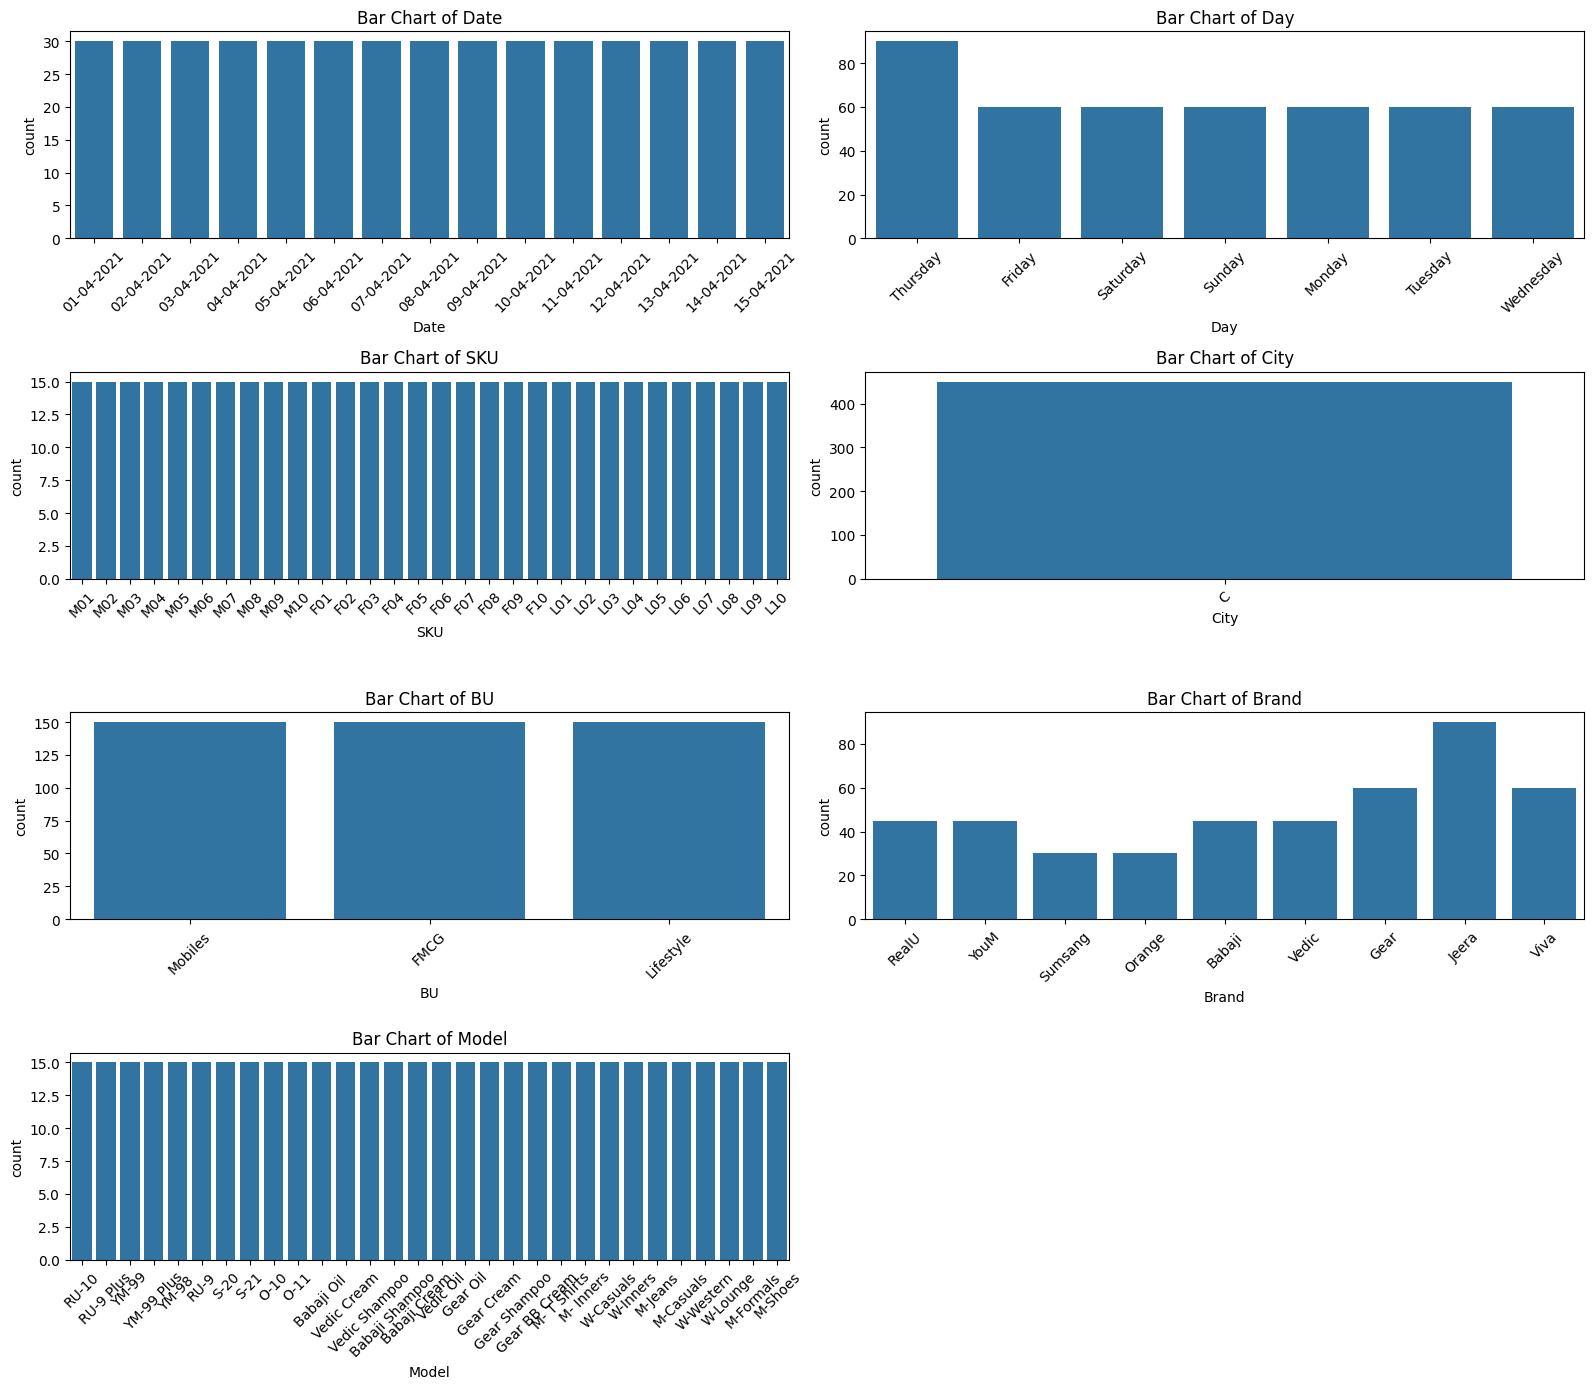

In [26]:
# Bar Charts for Categorical Variables

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 14))

for i, column in enumerate(categorical_columns.columns, 1):
    plt.subplot(4, 2, i)
    sns.countplot(x=df[column])
    plt.title(f"Bar Chart of {column}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Final Conclusion

In this project, descriptive analytics and data preprocessing were performed on the Sales and Discounts dataset to understand the behavior of sales, pricing, discounts, and net revenue.

The analysis of numerical columns using mean, median, mode, and standard deviation showed that most financial variables such as Avg Price, Total Sales Value, Discount Amount, and Net Sales Value are highly right-skewed. This indicates that while most transactions are small to medium in size, a few very large transactions significantly increase the average values.

The large differences between mean and median, along with high standard deviation values, confirmed the presence of strong variability and possible outliers in the dataset. This suggests that revenue is concentrated among fewer high-value transactions, which is a common business pattern in sales datasets.

The Discount Rate (%) column showed relatively low variation and a more balanced distribution, indicating that discount policies are more standardized and controlled compared to other financial variables.

Histogram analysis further confirmed the right-skewed nature of major financial columns, while boxplots clearly identified several upper-side outliers in Avg Price, Total Sales Value, Discount Amount, and Net Sales Value. These outliers may represent premium products, high-value customers, or special transactions and should be analyzed carefully rather than removed blindly.

Bar chart analysis of categorical columns helped identify dominant business segments and category distributions, providing insights into which products, regions, or customer groups contribute most to overall business performance.

Overall, the dataset reflects a business structure where a large portion of revenue is generated by a smaller number of high-value transactions, while most regular transactions remain lower in value. This insight is highly useful for pricing strategy, customer segmentation, discount optimization, and future business decision-making.

Thus, descriptive analytics and visualization provided valuable business understanding and prepared the dataset for further advanced analysis such as predictive modeling and machine learning.